# Market Experiment Results Analysis

Analysis notebook for LLM agent market experiments with tool usage.

- Tool usage analysis (code interpreter calls, tool arguments, results)
- Dedicated transaction log analysis
- Failed announcement detection (tool loop exhaustion)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import yaml
import ast

## 1. Load Data

In [5]:
# === CONFIGURE THIS ===
experiment_id = "test_tools_20260208_213107"

# paths
current_folder = globals()['_dh'][0]
results_path = os.path.join(current_folder, f'results/{experiment_id}')
figures_path = os.path.join(current_folder, 'plots')
os.makedirs(figures_path, exist_ok=True)

# read config
with open(os.path.join(results_path, 'config_used.yaml'), 'r') as f:
    config = yaml.safe_load(f)

exp_cfg = config['experiment']
N_SIMS = exp_cfg['n_simulations']
N_ROUNDS = exp_cfg['n_rounds']
N_ITER = exp_cfg['n_iterations']
MODEL = config['llm']['model']
TOOLS_ENABLED = config.get('tools', {}).get('enabled', False)

print(f"Experiment: {experiment_id}")
print(f"Model: {MODEL}")
print(f"Simulations: {N_SIMS}, Rounds: {N_ROUNDS}, Iterations: {N_ITER}")
print(f"Tools enabled: {TOOLS_ENABLED}")
print(f"Buyers: {exp_cfg['buyers']['num']} (prices {exp_cfg['buyers']['min']}-{exp_cfg['buyers']['max']})")
print(f"Sellers: {exp_cfg['sellers']['num']} (prices {exp_cfg['sellers']['min']}-{exp_cfg['sellers']['max']})")

Experiment: test_tools_20260208_213107
Model: gpt-4o-mini
Simulations: 1, Rounds: 1, Iterations: 3
Tools enabled: True
Buyers: 3 (prices 1.0-2.0)
Sellers: 3 (prices 1.0-2.0)


In [6]:
# load all simulation CSVs
iteration_histories = []
agent_histories = []
transactions = []
tool_usages = []

for sim in range(N_SIMS):
    data_dir = os.path.join(results_path, 'data')
    
    ih = pd.read_csv(os.path.join(data_dir, f'iteration_history_{sim+1}.csv'))
    iteration_histories.append(ih)
    
    ah = pd.read_csv(os.path.join(data_dir, f'agent_histories_{sim+1}.csv'))
    agent_histories.append(ah)
    
    tx = pd.read_csv(os.path.join(data_dir, f'transactions_{sim+1}.csv'))
    transactions.append(tx)
    
    tu_path = os.path.join(data_dir, f'tool_usage_{sim+1}.csv')
    if os.path.exists(tu_path):
        tu = pd.read_csv(os.path.join(data_dir, f'tool_usage_{sim+1}.csv'))
        tool_usages.append(tu)

# combine across simulations
df_iterations = pd.concat(
    [df.assign(sim=i+1) for i, df in enumerate(iteration_histories)],
    ignore_index=True
)
df_agents = pd.concat(
    [df.assign(sim=i+1) for i, df in enumerate(agent_histories)],
    ignore_index=True
)
df_transactions = pd.concat(
    [df.assign(sim=i+1) for i, df in enumerate(transactions)],
    ignore_index=True
)
if tool_usages:
    df_tools = pd.concat(
        [df.assign(sim=i+1) for i, df in enumerate(tool_usages)],
        ignore_index=True
    )
else:
    df_tools = pd.DataFrame()

print(f"Iteration history rows: {len(df_iterations)}")
print(f"Agent history rows: {len(df_agents)}")
print(f"Transactions: {len(df_transactions)}")
print(f"Tool usage rows: {len(df_tools)}")

Iteration history rows: 3
Agent history rows: 4
Transactions: 2
Tool usage rows: 10


In [7]:
# quick preview of each dataframe
print("=== Iteration History ===")
display(df_iterations.head())
print("\n=== Agent Histories ===")
display(df_agents.head())
print("\n=== Transactions ===")
display(df_transactions.head())
if not df_tools.empty:
    print("\n=== Tool Usage ===")
    display(df_tools.head())

=== Iteration History ===


,round,iteration,price,announcement_made,transaction_made,announcement_type,announcing_agent_id,announcing_agent_reservation_price,responding_agent_id,responding_agent_reservation_price,sim
0,1,1,1.5,True,True,sell,4,1.5,2.0,2.0,1
1,1,2,NaN,False,False,NaN,0,1.0,NaN,NaN,1
2,1,3,1.0,True,True,buy,0,1.0,3.0,1.0,1



=== Agent Histories ===


,agent_id,agent_type,reservation_price,round,iteration,action,price,outcome,sim
0,0,buyer,1.0,1,3,announce,1.0,accepted,1
1,2,buyer,2.0,1,1,respond,1.5,accepted,1
2,3,seller,1.0,1,3,respond,1.0,accepted,1
3,4,seller,1.5,1,1,announce,1.5,accepted,1



=== Transactions ===


,round,iteration,price,buyer_id,seller_id,announcement_type,sim
0,1,1,1.5,2,4,sell,1
1,1,3,1.0,0,3,buy,1



=== Tool Usage ===


,tool_name,tool_args,tool_result,iteration,agent_id,agent_type,action,round,simulation_id,sim
0,code_interpreter,{'code': 'reservation_price = 1.5\n\n# Since I...,result: 1.5,1,4,seller,announce,1,1,1
1,code_interpreter,{'code': 'reservation_price = 2.0\nproposed_pr...,result: 0.5,1,2,buyer,respond,1,1,1
2,code_interpreter,{'code': 'reservation_price = 1.0\nproposed_pr...,result: -0.5,2,0,buyer,announce,1,1,1
3,code_interpreter,"{'code': ""market_history = [{'round': 1, 'iter...",result: 1.5,2,0,buyer,announce,1,1,1
4,code_interpreter,"{'code': ""market_history = [{'round': 1, 'iter...",Code executed successfully with no output.,2,0,buyer,announce,1,1,1


## 2. Plotting Helpers

In [8]:
# consistent styling across all plots
COLORS = {
    'buyer': '#1f77b4',
    'seller': '#d62728',
    'avg': '#d62728',
    'equilibrium': 'grey',
}

def style_ax(ax, xlabel='', ylabel='', title=''):
    """Apply consistent thesis-quality styling to axes."""
    ax.set_xlabel(xlabel, fontsize=12, family='serif')
    ax.set_ylabel(ylabel, fontsize=12, family='serif')
    if title:
        ax.set_title(title, fontsize=14, family='serif', pad=10)
    ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_family('serif')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.grid(False)

## 3. Supply & Demand Diagram

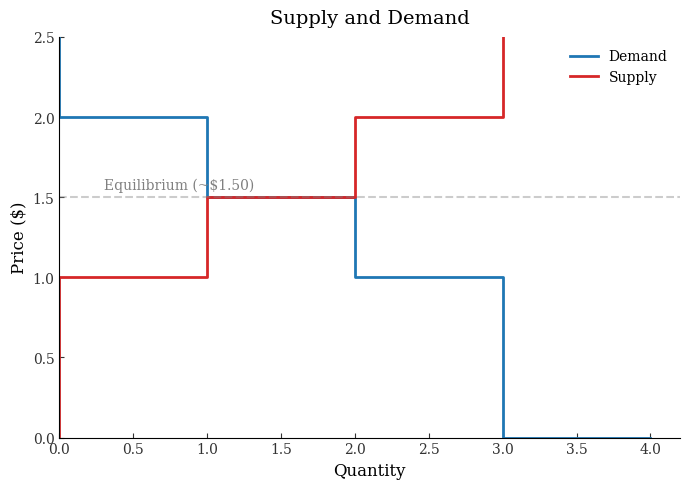

In [9]:
bp = exp_cfg['buyers']
sp = exp_cfg['sellers']

demand_p = np.round(np.linspace(bp['max'], bp['min'], bp['num']), 2)
supply_p = np.round(np.linspace(sp['min'], sp['max'], sp['num']), 2)
demand_q = np.arange(1, bp['num'] + 1)
supply_q = np.arange(1, sp['num'] + 1)

# extend for step plot
demand_q_ext = np.concatenate(([0], demand_q, [demand_q[-1] + 1]))
demand_p_ext = np.concatenate(([999], demand_p, [0]))
supply_q_ext = np.concatenate(([0], supply_q, [supply_q[-1] + 1]))
supply_p_ext = np.concatenate(([0], supply_p, [999]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.step(demand_q_ext, demand_p_ext, where='pre', label='Demand', color=COLORS['buyer'], linewidth=2)
ax.step(supply_q_ext, supply_p_ext, where='pre', label='Supply', color=COLORS['seller'], linewidth=2)

# equilibrium
eq_price = (bp['max'] + sp['min']) / 2  # rough midpoint
ax.axhline(y=eq_price, color='grey', linestyle='--', alpha=0.4)
ax.text(0.3, eq_price + 0.03, f'Equilibrium (~${eq_price:.2f})', color='grey', fontsize=10, va='bottom', family='serif')

ax.set_xlim(left=0)
ax.set_ylim(0, max(bp['max'], sp['max']) + 0.5)
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))
style_ax(ax, 'Quantity', 'Price ($)', 'Supply and Demand')
ax.legend(loc='upper right', frameon=False, prop={'family': 'serif', 'size': 10})
fig.tight_layout()
fig.savefig(os.path.join(figures_path, 'supply_demand_diagram.pdf'))
plt.show()

## 4. Transaction Price Over Rounds

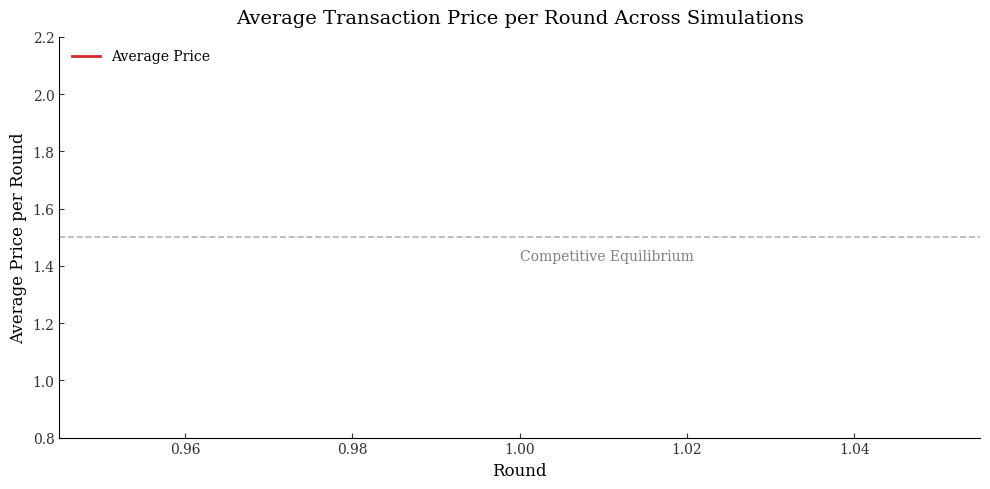

In [10]:
if len(df_transactions) == 0:
    print("No transactions to plot.")
else:
    sim_round_avg = df_transactions.groupby(['sim', 'round'])['price'].mean().reset_index()
    df_plot = sim_round_avg.pivot_table(index='round', columns='sim', values='price')

    fig, ax = plt.subplots(figsize=(10, 5))

    # individual simulations
    for sim_id in df_plot.columns:
        ax.plot(df_plot.index, df_plot[sim_id], color=COLORS['buyer'], alpha=0.3, linewidth=1)

    # average
    avg_prices = df_plot.mean(axis=1)
    ax.plot(df_plot.index, avg_prices, color=COLORS['avg'], linewidth=2, label='Average Price')

    # equilibrium
    ax.axhline(y=eq_price, color='grey', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.text(df_plot.index[0], eq_price - 0.08, 'Competitive Equilibrium', color='grey', fontsize=10, family='serif')

    style_ax(ax, 'Round', 'Average Price per Round', 'Average Transaction Price per Round Across Simulations')
    ax.set_ylim(sp['min'] - 0.2, bp['max'] + 0.2)
    ax.legend(loc='upper left', frameon=False, prop={'family': 'serif', 'size': 10})
    fig.tight_layout()
    fig.savefig(os.path.join(figures_path, 'avg_price_simulations.pdf'))
    plt.show()

## 5. Profit Analysis

In [11]:
# compute implied profit for each agent action
df_agents['implied_profit'] = np.where(
    df_agents['agent_type'] == 'buyer',
    df_agents['reservation_price'] - df_agents['price'],
    df_agents['price'] - df_agents['reservation_price']
)

# only realized (accepted) profits
df_profits_realized = (
    df_agents
    .loc[df_agents['outcome'] == 'accepted']
    .sort_values(by=['sim', 'round', 'iteration'])
    .reset_index(drop=True)
)

# pivot to get buyer/seller profits per transaction
df_profits = df_profits_realized.pivot_table(
    index=['sim', 'round', 'iteration'],
    columns='agent_type',
    values='implied_profit',
    aggfunc='first'
).reset_index()
df_profits.columns.name = None
df_profits = df_profits.rename(columns={'buyer': 'buyer_profit', 'seller': 'seller_profit'})

# identify who was the announcer
announcer = (
    df_profits_realized[df_profits_realized['action'] == 'announce']
    .set_index(['sim', 'round', 'iteration'])['agent_type']
)
df_profits = df_profits.merge(
    announcer.rename('announcer'),
    left_on=['sim', 'round', 'iteration'],
    right_index=True,
    how='left'
)

# announcer vs responder profit
df_profits['announcer_profit'] = np.where(
    df_profits['announcer'] == 'buyer',
    df_profits['buyer_profit'],
    df_profits['seller_profit']
)
df_profits['responder_profit'] = np.where(
    df_profits['announcer'] == 'seller',
    df_profits['buyer_profit'],
    df_profits['seller_profit']
)

print(f"Realized transactions: {len(df_profits)}")
display(df_profits.head())

Realized transactions: 2


,sim,round,iteration,buyer_profit,seller_profit,announcer,announcer_profit,responder_profit
0,1,1,1,0.5,0.0,seller,0.0,0.5
1,1,1,3,0.0,0.0,buyer,0.0,0.0


In [12]:
# profit statistics across simulations
def compute_profit_stats(df):
    n = len(df)
    if n == 0:
        return pd.Series(dtype=float)
    
    ann_buyer = df['announcer'] == 'buyer'
    ann_seller = df['announcer'] == 'seller'
    n_ab = ann_buyer.sum()
    n_as = ann_seller.sum()
    
    stats = {
        'zero_profit_announcers': (df['announcer_profit'] == 0).mean(),
        'zero_profit_responders': (df['responder_profit'] == 0).mean(),
        'avg_profit_announcers': df['announcer_profit'].mean(),
        'avg_profit_responders': df['responder_profit'].mean(),
        'share_buy_announcers': ann_buyer.mean(),
    }
    
    if n_ab > 0:
        stats['avg_profit_announcer_buyers'] = df.loc[ann_buyer, 'announcer_profit'].mean()
    if n_as > 0:
        stats['avg_profit_announcer_sellers'] = df.loc[ann_seller, 'announcer_profit'].mean()
    
    return pd.Series(stats)

sim_stats = df_profits.groupby('sim').apply(compute_profit_stats, include_groups=False)
mean_stats = sim_stats.mean()
std_stats = sim_stats.std()

print("Profit statistics (mean ± std across simulations):\n")
for col in mean_stats.index:
    label = col.replace('_', ' ').title()
    print(f"  {label}: {mean_stats[col]:.3f} ± {std_stats[col]:.3f}")

Profit statistics (mean ± std across simulations):

  Zero Profit Announcers: 1.000 ± nan
  Zero Profit Responders: 0.500 ± nan
  Avg Profit Announcers: 0.000 ± nan
  Avg Profit Responders: 0.250 ± nan
  Share Buy Announcers: 0.500 ± nan
  Avg Profit Announcer Buyers: 0.000 ± nan
  Avg Profit Announcer Sellers: 0.000 ± nan


## 6. Announcement Analysis

In [13]:
# successful announcements (price was parsed)
df_announced = df_iterations[df_iterations['announcement_made'] == True].copy()
df_announced['deviation'] = df_announced['price'] - df_announced['announcing_agent_reservation_price']

# failed announcements (no price parsed / tool loop exhaustion)
df_failed = df_iterations[df_iterations['announcement_made'] == False]

n_announced = len(df_announced)
n_failed = len(df_failed)
n_total = n_announced + n_failed

print(f"Announcements: {n_announced} successful, {n_failed} failed out of {n_total} total")
print(f"Failure rate: {n_failed / n_total:.1%}" if n_total > 0 else "")

if n_announced > 0:
    # reservation price adherence
    for atype in ['buy', 'sell']:
        mask = df_announced['announcement_type'] == atype
        if mask.sum() > 0:
            at_res = (df_announced.loc[mask, 'deviation'] == 0).mean()
            accepted = df_announced.loc[mask, 'transaction_made'].mean()
            print(f"\n{atype.capitalize()} announcements:")
            print(f"  At reservation price: {at_res:.1%}")
            print(f"  Accepted: {accepted:.1%}")
            print(f"  Mean deviation: {df_announced.loc[mask, 'deviation'].mean():.3f}")

Announcements: 2 successful, 1 failed out of 3 total
Failure rate: 33.3%

Buy announcements:
  At reservation price: 100.0%
  Accepted: 100.0%
  Mean deviation: 0.000

Sell announcements:
  At reservation price: 100.0%
  Accepted: 100.0%
  Mean deviation: 0.000


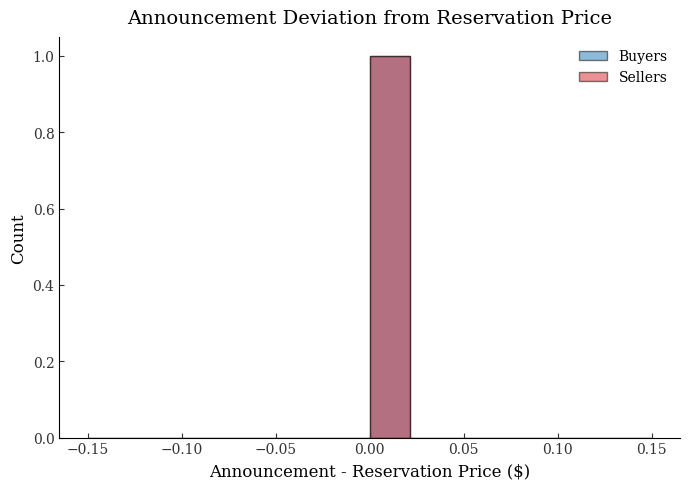

In [14]:
# announcement deviation histogram
if n_announced > 0:
    fig, ax = plt.subplots(figsize=(7, 5))
    
    buy_dev = df_announced.loc[df_announced['announcement_type'] == 'buy', 'deviation']
    sell_dev = df_announced.loc[df_announced['announcement_type'] == 'sell', 'deviation']
    
    max_dev = max(abs(df_announced['deviation'].min()), abs(df_announced['deviation'].max()), 0.1)
    bins = np.linspace(-max_dev - 0.05, max_dev + 0.05, 15)
    
    if len(buy_dev) > 0:
        ax.hist(buy_dev, bins=bins, alpha=0.5, color=COLORS['buyer'], edgecolor='k', label='Buyers')
    if len(sell_dev) > 0:
        ax.hist(sell_dev, bins=bins, alpha=0.5, color=COLORS['seller'], edgecolor='k', label='Sellers')
    
    style_ax(ax, 'Announcement - Reservation Price ($)', 'Count', 'Announcement Deviation from Reservation Price')
    ax.legend(frameon=False, prop={'family': 'serif', 'size': 10})
    fig.tight_layout()
    fig.savefig(os.path.join(figures_path, 'announcement_deviation.pdf'))
    plt.show()

## 7. Profit Distribution

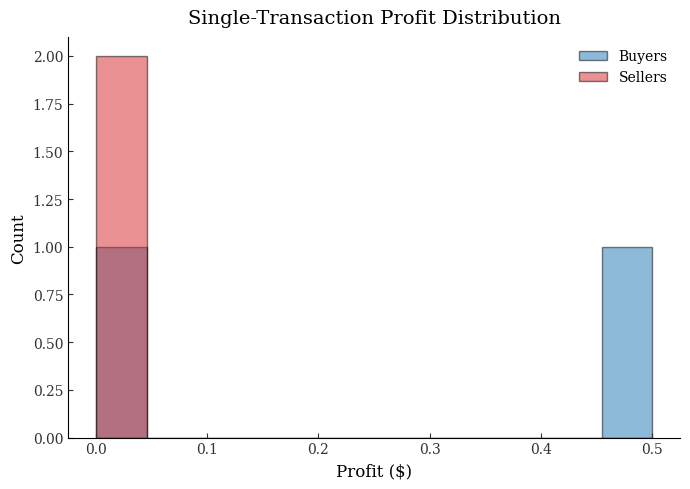

In [15]:
if len(df_profits) > 0:
    fig, ax = plt.subplots(figsize=(7, 5))
    
    max_profit = df_profits[['buyer_profit', 'seller_profit']].max().max()
    bins = np.linspace(0, max(max_profit, 0.1), 12)
    
    ax.hist(df_profits['buyer_profit'].dropna(), bins=bins, alpha=0.5,
            color=COLORS['buyer'], edgecolor='k', label='Buyers')
    ax.hist(df_profits['seller_profit'].dropna(), bins=bins, alpha=0.5,
            color=COLORS['seller'], edgecolor='k', label='Sellers')
    
    style_ax(ax, 'Profit ($)', 'Count', 'Single-Transaction Profit Distribution')
    ax.legend(frameon=False, prop={'family': 'serif', 'size': 10})
    fig.tight_layout()
    fig.savefig(os.path.join(figures_path, 'profit_distribution.pdf'))
    plt.show()

## 8. Response Acceptance Rate vs Reservation Price

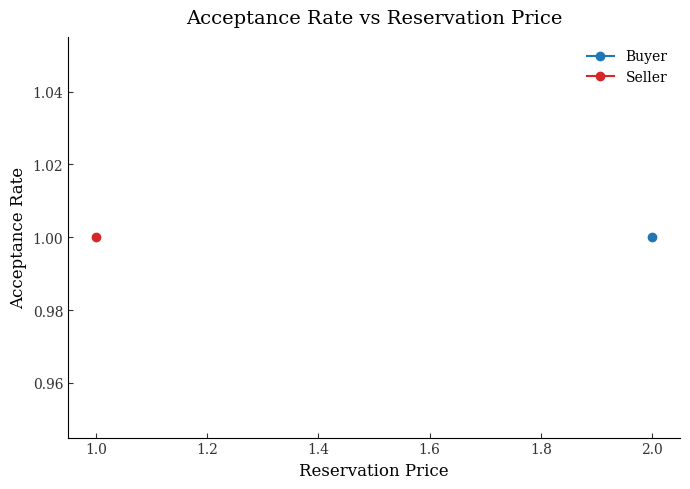

In [16]:
df_responses = df_agents[df_agents['action'] == 'respond'].copy()

if len(df_responses) > 0:
    resp_agg = (
        df_responses
        .groupby(['sim', 'agent_type', 'agent_id', 'reservation_price', 'outcome'])
        .size()
        .reset_index(name='count')
    )
    resp_pivot = resp_agg.pivot_table(
        index=['sim', 'agent_type', 'agent_id', 'reservation_price'],
        columns='outcome', values='count', fill_value=0
    ).reset_index()
    
    if 'accepted' not in resp_pivot.columns:
        resp_pivot['accepted'] = 0
    if 'rejected' not in resp_pivot.columns:
        resp_pivot['rejected'] = 0
    
    resp_pivot['total'] = resp_pivot['accepted'] + resp_pivot['rejected']
    resp_pivot['acceptance_rate'] = resp_pivot['accepted'] / resp_pivot['total']
    
    agg = resp_pivot.groupby(['agent_type', 'reservation_price']).agg(
        mean_rate=('acceptance_rate', 'mean'),
        se=('acceptance_rate', lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0)
    ).reset_index()
    agg['ci95'] = 1.96 * agg['se']
    
    fig, ax = plt.subplots(figsize=(7, 5))
    for t in agg['agent_type'].unique():
        df_t = agg[agg['agent_type'] == t].sort_values('reservation_price')
        ax.plot(df_t['reservation_price'], df_t['mean_rate'],
                marker='o', color=COLORS.get(t, 'grey'), label=t.capitalize())
        ax.fill_between(df_t['reservation_price'],
                        df_t['mean_rate'] - df_t['ci95'],
                        df_t['mean_rate'] + df_t['ci95'],
                        color=COLORS.get(t, 'grey'), alpha=0.3)
    
    style_ax(ax, 'Reservation Price', 'Acceptance Rate', 'Acceptance Rate vs Reservation Price')
    ax.legend(frameon=False, prop={'family': 'serif', 'size': 10})
    fig.tight_layout()
    fig.savefig(os.path.join(figures_path, 'acceptance_rate.pdf'))
    plt.show()

---

## 9. Tool Usage Analysis


In [17]:
if df_tools.empty:
    print("No tool usage data available.")
else:
    print(f"Total tool calls: {len(df_tools)}")
    print(f"\nTool calls by tool name:")
    print(df_tools['tool_name'].value_counts().to_string())
    print(f"\nTool calls by agent type:")
    print(df_tools.groupby('agent_type').size().to_string())
    print(f"\nTool calls by action (announce vs respond):")
    print(df_tools.groupby('action').size().to_string())

Total tool calls: 10

Tool calls by tool name:
tool_name
code_interpreter    10

Tool calls by agent type:
agent_type
buyer     7
seller    3

Tool calls by action (announce vs respond):
action
announce    7
respond     3


In [18]:
# tool calls per decision (per agent per iteration)
if not df_tools.empty:
    calls_per_decision = (
        df_tools
        .groupby(['sim', 'round', 'iteration', 'agent_id', 'action'])
        .size()
        .reset_index(name='n_tool_calls')
    )
    
    print("Tool calls per decision:")
    print(f"  Mean: {calls_per_decision['n_tool_calls'].mean():.2f}")
    print(f"  Median: {calls_per_decision['n_tool_calls'].median():.1f}")
    print(f"  Max: {calls_per_decision['n_tool_calls'].max()}")
    print(f"  Distribution:")
    print(calls_per_decision['n_tool_calls'].value_counts().sort_index().to_string())
    
    # max tool iterations from config
    max_iter = config.get('tools', {}).get('max_tool_iterations', None)
    if max_iter:
        exhausted = (calls_per_decision['n_tool_calls'] >= max_iter).sum()
        print(f"\n  Decisions hitting max tool iterations ({max_iter}): {exhausted} / {len(calls_per_decision)}")

Tool calls per decision:
  Mean: 1.67
  Median: 1.0
  Max: 5
  Distribution:
n_tool_calls
1    5
5    1

  Decisions hitting max tool iterations (5): 1 / 6


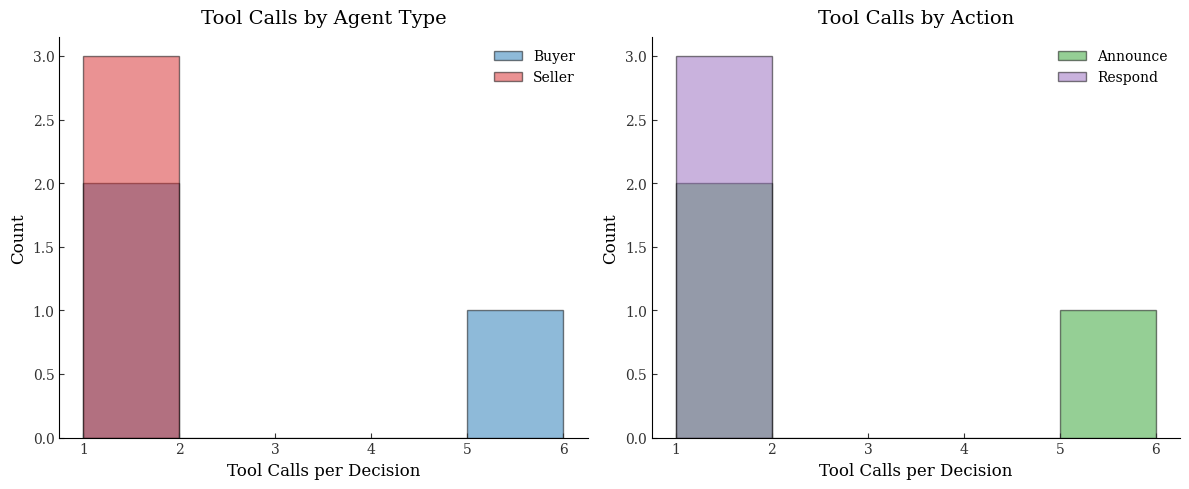

In [19]:
# tool calls per decision - visualization
if not df_tools.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # by agent type
    calls_by_type = (
        df_tools
        .groupby(['sim', 'round', 'iteration', 'agent_id', 'agent_type', 'action'])
        .size()
        .reset_index(name='n_tool_calls')
    )
    
    for agent_type, color in COLORS.items():
        if agent_type not in ('buyer', 'seller'):
            continue
        data = calls_by_type.loc[calls_by_type['agent_type'] == agent_type, 'n_tool_calls']
        if len(data) > 0:
            axes[0].hist(data, alpha=0.5, color=color, edgecolor='k', label=agent_type.capitalize(),
                        bins=range(1, data.max() + 2))
    style_ax(axes[0], 'Tool Calls per Decision', 'Count', 'Tool Calls by Agent Type')
    axes[0].legend(frameon=False, prop={'family': 'serif', 'size': 10})
    
    # by action
    for action, color in [('announce', '#2ca02c'), ('respond', '#9467bd')]:
        data = calls_by_type.loc[calls_by_type['action'] == action, 'n_tool_calls']
        if len(data) > 0:
            axes[1].hist(data, alpha=0.5, color=color, edgecolor='k', label=action.capitalize(),
                        bins=range(1, data.max() + 2))
    style_ax(axes[1], 'Tool Calls per Decision', 'Count', 'Tool Calls by Action')
    axes[1].legend(frameon=False, prop={'family': 'serif', 'size': 10})
    
    fig.tight_layout()
    fig.savefig(os.path.join(figures_path, 'tool_calls_distribution.pdf'))
    plt.show()

In [20]:
# what are agents computing? inspect code interpreter usage
if not df_tools.empty and 'code_interpreter' in df_tools['tool_name'].values:
    ci_calls = df_tools[df_tools['tool_name'] == 'code_interpreter'].copy()
    
    # extract the code from tool_args
    def extract_code(args_str):
        try:
            args = ast.literal_eval(args_str)
            return args.get('code', args_str)
        except (ValueError, SyntaxError):
            return args_str
    
    ci_calls['code'] = ci_calls['tool_args'].apply(extract_code)
    
    # categorize code patterns
    def categorize_code(code):
        code_lower = code.lower()
        if 'profit' in code_lower or 'loss' in code_lower:
            return 'profit_calculation'
        elif 'average' in code_lower or 'mean' in code_lower or 'market_history' in code_lower:
            return 'market_analysis'
        elif 'spread' in code_lower or 'bid' in code_lower or 'ask' in code_lower:
            return 'spread_analysis'
        elif 'inframarginal' in code_lower or 'extramarginal' in code_lower or 'classify' in code_lower:
            return 'trader_classification'
        elif 'reservation' in code_lower and 'price' in code_lower:
            return 'price_setting'
        elif 'acceptance' in code_lower:
            return 'acceptance_analysis'
        else:
            return 'other'
    
    ci_calls['code_category'] = ci_calls['code'].apply(categorize_code)
    
    print("Code interpreter usage by category:")
    print(ci_calls['code_category'].value_counts().to_string())
    
    print("\nBy agent type and action:")
    print(ci_calls.groupby(['agent_type', 'action', 'code_category']).size()
          .reset_index(name='count')
          .sort_values(['agent_type', 'action', 'count'], ascending=[True, True, False])
          .to_string(index=False))

Code interpreter usage by category:
code_category
market_analysis       5
profit_calculation    4
spread_analysis       1

By agent type and action:
agent_type   action      code_category  count
     buyer announce    market_analysis      5
     buyer announce profit_calculation      1
     buyer  respond profit_calculation      1
    seller announce    spread_analysis      1
    seller  respond profit_calculation      2


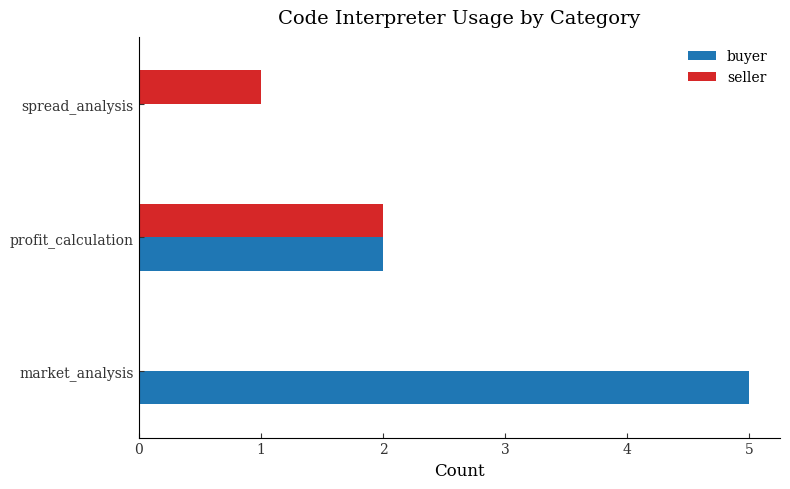

In [21]:
# code category distribution chart
if not df_tools.empty and 'code_interpreter' in df_tools['tool_name'].values:
    cat_counts = ci_calls.groupby(['agent_type', 'code_category']).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    cat_counts.T.plot(kind='barh', ax=ax, color=[COLORS.get(c, 'grey') for c in cat_counts.index])
    style_ax(ax, 'Count', '', 'Code Interpreter Usage by Category')
    ax.legend(frameon=False, prop={'family': 'serif', 'size': 10})
    fig.tight_layout()
    fig.savefig(os.path.join(figures_path, 'tool_code_categories.pdf'))
    plt.show()

## 10. Summary Table

In [24]:
# summary of key metrics
summary = {
    'Experiment': experiment_id,
    'Model': MODEL,
    'Tools Enabled': TOOLS_ENABLED,
    'Simulations': N_SIMS,
    'Rounds': N_ROUNDS,
    'Iterations per Round': N_ITER,
    'Total Transactions': len(df_transactions),
    'Mean Transaction Price': f"${df_transactions['price'].mean():.2f}" if len(df_transactions) > 0 else 'N/A',
    'Announcement Success Rate': f"{n_announced / n_total:.1%}" if n_total > 0 else 'N/A',
    'Total Tool Calls': len(df_tools) if not df_tools.empty else 0,
}

if len(df_profits) > 0:
    summary['Mean Buyer Profit'] = f"${df_profits['buyer_profit'].mean():.3f}"
    summary['Mean Seller Profit'] = f"${df_profits['seller_profit'].mean():.3f}"

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
display(summary_df.style.hide(axis='index'))

Metric,Value
Experiment,test_tools_20260208_213107
Model,gpt-4o-mini
Tools Enabled,True
Simulations,1
Rounds,1
Iterations per Round,3
Total Transactions,2
Mean Transaction Price,$1.25
Announcement Success Rate,66.7%
Total Tool Calls,10
